# Multiple Layer Perceptron Hands-on using `IRIS` dataset; building from scratch

![image.png](attachment:746d44bd-a7e6-4cd7-ac8d-17584e0cade4.png)

- `3 Categories / classes` 150 rows /instances equally distributed across 3 categories --> **Perfectly Balanced Dataset**

- 4 Features or Input Variables

- https://archive.ics.uci.edu/dataset/53/iris

#### `Accuracy` benchmarking across multiple models on `IRIS`

![image.png](attachment:1ba80661-34bc-4ab1-b90b-951b5448c8de.png)

#### `Precision` benchmarking across multiple models on `IRIS`

![image.png](attachment:21cdab1f-92b0-4092-af47-8b418ff9bead.png)

#### Import certain libraries

In [ ]:
import numpy as np
import pandas as pd
import os

import matplotlib.pyplot as plt
import seaborn as sns

##### To get the current working directory

In [ ]:
os.getcwd()

'C:\\Users\\ask2a\\OneDrive\\TRAINING\\INTELLIPAAT\\DEEP LEARNING\\13. AI and DL IITR-23May2026(E)'

In [ ]:
os.listdir()

['.ipynb_checkpoints',
 'Benchmarking Models across different use-cases_31May2026.ipynb',
 'Building ANN Models_31May.pdf',
 'Course Structure_23May.pdf',
 'customer_churn_dataset.csv',
 'Deep Learning Kick-Off Session_23May.pdf',
 'digit_data.csv',
 'fraud_detection_dataset.csv',
 'Industrial Applications or Use-cases_24May.pdf',
 'IRIS_24May.xlsx',
 'Let us build an App_24May.pdf',
 'loan_approval_dataset.csv',
 'MLP Model Build from Scratch_07June.pdf',
 'MLP model using IRIS from Scratch_07June.ipynb',
 'MLP model using IRIS from Scratch_13June.ipynb',
 'mnist_train_31May.xlsx',
 'Module 1  Introduction to Deep Learning_23May.pdf',
 'Module 1  Introduction to Deep Learning_24May.pdf',
 'Module 2  Artificial Neural Networks (ANNs)_30May.pdf',
 'Module 2  Artificial Neural Networks (ANNs)_31May.pdf',
 'Multiple Layer Perceptron (MLP)_06June.pdf',
 'Multiple Layer Perceptron (MLP)_07June.pdf',
 'neural_network_playground_dataset.csv',
 'playground_viz.png',
 'Prompt Engineering_31May.

#### Load the `IRIS` data directly from `sklearn`

In [ ]:
from sklearn.datasets import load_iris

In [ ]:
#### Loading the IRIS dataset
iris = load_iris() #iris object

In [ ]:
type(iris)

sklearn.utils._bunch.Bunch

- https://scikit-learn.org/stable/modules/generated/sklearn.utils.Bunch.html

In [ ]:
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [ ]:
### Show the feature names for IRIS
iris['feature_names']

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [ ]:
iris_df = pd.DataFrame(data = iris['data'], columns=iris['feature_names'])
iris_df.sample(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
141,6.9,3.1,5.1,2.3
88,5.6,3.0,4.1,1.3
78,6.0,2.9,4.5,1.5
5,5.4,3.9,1.7,0.4
49,5.0,3.3,1.4,0.2


In [ ]:
### Let us add the `target` variable
iris_df['target'] = iris['target']
iris_df.sample(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
132,6.4,2.8,5.6,2.2,2
101,5.8,2.7,5.1,1.9,2
31,5.4,3.4,1.5,0.4,0
147,6.5,3.0,5.2,2.0,2
109,7.2,3.6,6.1,2.5,2


In [ ]:
iris['data']

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [ ]:
iris['target']

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

### Let us convert `Label Encoding` to `One-Hot Encoding`

In [ ]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
### Initialize the OneHotEncoder
encoder = OneHotEncoder(sparse_output= False)

In [ ]:
#### Reshape y to a 2D array (-1, 1) as required Sklearn
y_reshaped = iris.target.reshape(-1,1)
y_reshaped[:5] #2D-Array

array([[0],
       [0],
       [0],
       [0],
       [0]])

In [ ]:
iris.target[:5] #1-D Array

array([0, 0, 0, 0, 0])

In [ ]:
y_one_hot = encoder.fit_transform(y_reshaped)
y_one_hot

array([[1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0

**TASK: Pls read about:**
- Label Encoding vs One-Hot Encoding
- What are different functions to OHE? - Try with Pandas - `pd.get_dummies`
- Build a `Random Forest` model for IRIS using LE as well as OHE & benchmark Accuracy & Precision and compare with UCI
- Revise OOPs principles

### `Pandas: pd.get_dummies`

In [ ]:
iris_df = pd.DataFrame(iris.data, columns =iris.feature_names)
iris_df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)
iris_df.sample(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
21,5.1,3.7,1.5,0.4,setosa
71,6.1,2.8,4.0,1.3,versicolor
40,5.0,3.5,1.3,0.3,setosa
75,6.6,3.0,4.4,1.4,versicolor
131,7.9,3.8,6.4,2.0,virginica


In [ ]:
print('Before apply get_dummies:')
print(iris_df[['species']].head())

Before apply get_dummies:
  species
0  setosa
1  setosa
2  setosa
3  setosa
4  setosa


In [ ]:
iris_dummies = pd.get_dummies(iris_df,
                              columns=['species'],
                              drop_first=False) #this is the parameter used to avoid the Dummy Variable Trap - if set to True, it drops the first generated category column in this case: 'setosa'
iris_dummies.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_setosa,species_versicolor,species_virginica
0,5.1,3.5,1.4,0.2,True,False,False
1,4.9,3.0,1.4,0.2,True,False,False
2,4.7,3.2,1.3,0.2,True,False,False
3,4.6,3.1,1.5,0.2,True,False,False
4,5.0,3.6,1.4,0.2,True,False,False


In [ ]:
iris_dummies = pd.get_dummies(iris_df,
                              columns=['species'],
                              drop_first=True) #this is the parameter used to avoid the Dummy Variable Trap - if set to True, it drops the first generated category column in this case: 'setosa'
iris_dummies.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_versicolor,species_virginica
0,5.1,3.5,1.4,0.2,False,False
1,4.9,3.0,1.4,0.2,False,False
2,4.7,3.2,1.3,0.2,False,False
3,4.6,3.1,1.5,0.2,False,False
4,5.0,3.6,1.4,0.2,False,False


![image.png](attachment:0f075a9c-346e-4dac-8489-c1f490206a86.png)

## Build the `MLP` Model

In [ ]:
class NeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.01, epochs=100):
        self.input_size = input_size # no. of neurons in the IL -> as many features in the training dataset that many neurons in the IL
        self.hidden_size = hidden_size #no. of neurons in the hidden layer
        self.output_size = output_size #no. of neurons in the output layer
        self.learning_rate = learning_rate #to set the user defined (modeller's choice) learning rate for the gradient descent; default is set to 0.01
        self.epochs = epochs #no. of training epochsm default is set to 100

        # Initialize weights & biases
        #################################
        # INPUT LAYER TO HIDDEN LAYER
        #################################
        self.W1 = np.random.randn(self.input_size, self.hidden_size)*0.01 #random weights initialized from std. normal distribution and then scaled by 0.01
        self.b1 = np.zeros((1, self.hidden_size))

        #################################
        # HIDDEN LAYER TO OUTPUT LAYER
        #################################
        self.W2 = np.random.randn(self.hidden_size, self.output_size)*0.01 #random weights initialized from std. normal distribution and then scaled by 0.01
        self.b2 = np.zeros((1, self.output_size))

        ######################################
        # COST & ACCURACY HISTORY FOR PLOTTING
        #######################################
        self.loss_history = [] #empty list initialized to store the losses during training epochs
        self.accuracy_history = [] #empty list initialized to store the accuracy values during training epochs

    #### ADD SOME OF THE ACTIVATION FUNCTION

    #1. ReLU Activation Function
    def relu(self, z):
        return np.maximum(0, z)

    #2. Derivative of ReLU for backpropagation
    def relu_derivative(self, z):
        return np.where(z>0, 1, 0)

    #3. Softmax Activation Function
    def softmax(self, z):
        exp_values = np.exp(z - np.max(z, axis=1, keepdims=True)) #subtract max for numerical stability -- numerical stability (read about it)
        return exp_values/(np.sum(exp_values, axis=1, keepdims=True))

    ##################################
      #1. FORWARD PROPAGATION
    #################################

    def forward(self, X):

        # INPUT LAYER to HIDDEN LAYER
        self.z1 = np.dot(X, self.W1) + self.b1 #Computing weighted sum of inputs along with bias
        self.a1 = self.relu(self.z1) # plugging z1 into ReLU activation function to get output as activation value a1

        # HIDDEN LAYER to OUTPUT LAYER
        self.z2 = np.dot(self.a1, self.W2) + self.b2 #computing weighted sum of activated inputs along with bias
        self.probs = self.softmax(self.z2) # plug z2 into softmax activation function to get output as probabilities
        return self.probs


    ##################################
      #2. COMPUTE LOSS & ACCURACY
    #################################

    ### Cross-entropy loss for multi-class classification
    def compute_loss(self, y_true, probs):
        loss = -np.mean(np.sum(y_true * np.log(probs), axis=1))
        return loss

    ### Compute Accuracy
    def compute_accuracy(self, y_true, probs):
        predictions = np.argmax(probs, axis =1)
        true_labels = np.argmax(y_true, axis=1)
        return np.mean(predictions == true_labels)


    ##################################
      #3.BACKPROPAGATION
    #################################
    def backward(self, X , y):

        ### Using Batch Gradient Descent (BGD)

        ### Number of rows/training examples
        m = X.shape[0] #all rows in the data

        ###Gradients of the loss w.r.t. weights and biases of the output layer
        delta3 = self.probs - y #error at the output layer
        dW2 = np.dot(self.a1.T, delta3)/m #gradient of the loss w.r.t. weights of the output layer --> dW2
        db2 = np.sum(delta3, axis=0, keepdims= True)/m #gradient of the loss w.r.t. bias of the output layer --> db2

        ### Gradients of the loss w.r.t. weights and biases of the hidden layer
        delta2 = np.dot(delta3, self.W2.T)*self.relu_derivative(self.z1)#using derivative of ReLU
        dW1 = np.dot(X.T, delta2)/m #gradient of the loss w.r.t weights of the hidden layer --> dW1
        db1 = np.sum(delta2, axis=0, keepdims= True)/m #gradient of the loss w.r.t. bias of the hidden layer --> db1

        ### Update weights & biases parameters across the layers (Hidden layer & Output layer)
        self.W2 -= self.learning_rate* dW2
        self.b2 -= self.learning_rate * db2
        self.W1 -= self.learning_rate * dW1
        self.b1 -= self.learning_rate * db1


    ##################################
      # MLP TRAIN
    #################################
    def train(self, X, y):
        for epoch in range(self.epochs):

            ### 1. Forward Pass
            probs = self.forward(X) # computes the prediction using forward pass method

            ### 2. Compute the loss and find accuracy
            loss = self.compute_loss(y, probs)
            accuracy = self.compute_accuracy(y, probs)

            ### 3. Store the loss and accuracy values historically after every epoch
            self.loss_history.append(loss)
            self.accuracy_history.append(accuracy)

            ### 4. Backward Pass
            self.backward(X, y)

            ### 5. Printing the progress after every 10 epochs
            if epoch % 10 == 0:
                print(f'Training Metrics: Epoch: {epoch}, Loss: {loss: .4f}, Accuracy: {accuracy:.4f}')



### Initialize the `IRIS MLP` Neural Network Model

In [ ]:
input_size = 4 #number of neurons = number of features in IRIS dataset which is 4
hidden_size = 8 #number of neurons in the hidden layer
output_size = 3 #number of neurons = number of classes in IRIS dataset which is 3 species of the IRIS flower

- Since the IRIS dataset has `label encoding` which we need to change it to `One-Hot Encoding`

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

In [ ]:
X = iris.data #input variables / features
y = iris.target #output

In [ ]:
encoder = OneHotEncoder(sparse_output=False)
y = encoder.fit_transform(y.reshape(-1,1))
y[:10]

array([[1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.]])

### Split the data into `train` and `test` datasets

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (120, 4)
Test Shape: (30, 4)


### `Fire our very own **MLP Model**

In [ ]:
del nn_iris # to ensure that you are starting with a clean slate

In [ ]:
nn_iris = NeuralNetwork(input_size, hidden_size, output_size, learning_rate=0.04, epochs=500) # configuring the architecture of NN model

### Run `training` using already configures `MLP NN` model on the X_train

In [ ]:
nn_iris.train(X_train, y_train)

Training Metrics: Epoch: 0, Loss:  1.0986, Accuracy: 0.4583
Training Metrics: Epoch: 10, Loss:  1.0982, Accuracy: 0.3417
Training Metrics: Epoch: 20, Loss:  1.0977, Accuracy: 0.3417
Training Metrics: Epoch: 30, Loss:  1.0965, Accuracy: 0.3417
Training Metrics: Epoch: 40, Loss:  1.0940, Accuracy: 0.3417
Training Metrics: Epoch: 50, Loss:  1.0886, Accuracy: 0.5833
Training Metrics: Epoch: 60, Loss:  1.0780, Accuracy: 0.3250
Training Metrics: Epoch: 70, Loss:  1.0592, Accuracy: 0.3250
Training Metrics: Epoch: 80, Loss:  1.0300, Accuracy: 0.3250
Training Metrics: Epoch: 90, Loss:  0.9868, Accuracy: 0.5500
Training Metrics: Epoch: 100, Loss:  0.9268, Accuracy: 0.6583
Training Metrics: Epoch: 110, Loss:  0.8623, Accuracy: 0.6583
Training Metrics: Epoch: 120, Loss:  0.7952, Accuracy: 0.6583
Training Metrics: Epoch: 130, Loss:  0.7238, Accuracy: 0.6583
Training Metrics: Epoch: 140, Loss:  0.6547, Accuracy: 0.6667
Training Metrics: Epoch: 150, Loss:  0.5960, Accuracy: 0.6917
Training Metrics: E

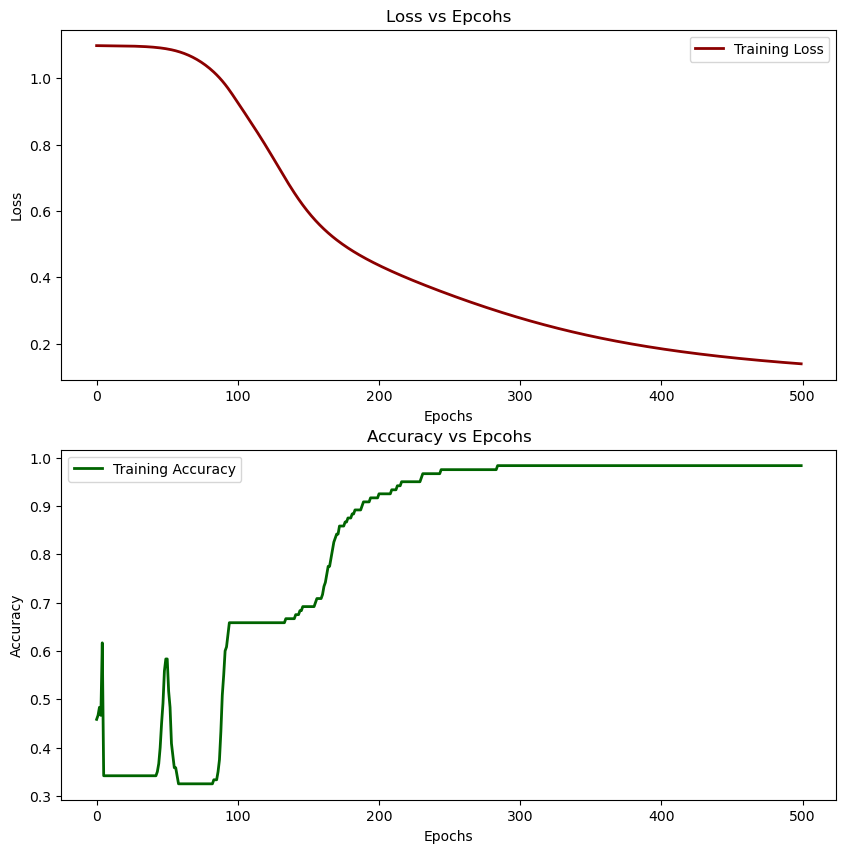

In [ ]:
fig, ax = plt.subplots(2,1, figsize = (10,10))

### Plot the loss by epoch
ax[0].plot(nn_iris.loss_history, label = 'Training Loss', color= 'darkred', linewidth =2)
ax[0].set_title('Loss vs Epcohs')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].legend()


### Plot the accuracy by epoch
ax[1].plot(nn_iris.accuracy_history, label = 'Training Accuracy', color= 'darkgreen', linewidth =2)
ax[1].set_title('Accuracy vs Epcohs')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy')
ax[1].legend()

plt.show()

### Tiny blocks to understand the code better

In [ ]:

        # Initialize weights & biases
        #################################
        # INPUT LAYER TO HIDDEN LAYER
        #################################
        self.W1 = np.random.randn(self.input_size, self.hidden_size)*0.01 #random weights initialized from std. normal distribution and then scaled by 0.01
        self.b1 = np.zeros((1, self.hidden_size))

        #################################
        # HIDDEN LAYER TO OUTPUT LAYER
        #################################
        self.W2 = np.random.randn(self.hidden_size, self.output_size)*0.01 #random weights initialized from std. normal distribution and then scaled by 0.01
        self.b2 = np.zeros((1, self.output_size))

In [ ]:
np.random.randn(4, 8)*.01

array([[-0.00477144, -0.012819  , -0.00841658, -0.00038486, -0.00681637,
        -0.01372009, -0.00498632, -0.00652698],
       [-0.01627967,  0.01796693, -0.01006119, -0.01640812,  0.00247517,
        -0.0024484 , -0.00759239,  0.00499148],
       [-0.00759789, -0.00017785,  0.00120977, -0.01935519,  0.01887831,
        -0.02348635, -0.00252479, -0.00132742],
       [ 0.00623614,  0.00392673,  0.00143675, -0.00027766, -0.01584522,
         0.01164137, -0.01130483, -0.01647222]])

In [ ]:
np.random.randn(4, 8).shape

(4, 8)

In [ ]:
np.zeros((1, 8))

array([[0., 0., 0., 0., 0., 0., 0., 0.]])

In [ ]:
np.zeros((1, 8)).shape


(1, 8)

### Understanding the `loss` and `accuracy` function

In [ ]:
y_true

array([[1, 0, 0],
       [0, 1, 0],
       [0, 0, 1]])

In [ ]:
probs

array([[0.7, 0.2, 0.1],
       [0.1, 0.8, 0.1],
       [0.2, 0.2, 0.6]])

In [ ]:
y_true * np.log(probs)

array([[-0.35667494, -0.        , -0.        ],
       [-0.        , -0.22314355, -0.        ],
       [-0.        , -0.        , -0.51082562]])

In [ ]:
-np.mean(np.sum(y_true * np.log(probs), axis=1))

np.float64(0.3635480396729776)

In [ ]:
# 3 samples, 3 classes (Cat, Dog, Bird)
y_true = np.array([
    [1, 0, 0],   # sample 1 = Cat
    [0, 1, 0],   # sample 2 = Dog
    [0, 0, 1],   # sample 3 = Bird
])

# Model's predicted probabilities (must sum to 1 per row)
probs = np.array([
    [0.7, 0.2, 0.1],   # predicted: 70% Cat  ✓
    [0.1, 0.8, 0.1],   # predicted: 80% Dog  ✓
    [0.2, 0.2, 0.6],   # predicted: 60% Bird ✓
])

# ── Cross-Entropy Loss ──────────────────────────────────
# For each sample: sum(y_true * log(probs)) picks out
# only the log-prob of the CORRECT class (others are 0)
# Then average and negate → lower is better
loss = -np.mean(np.sum(y_true * np.log(probs), axis=1))
print(f"Loss: {loss:.4f}")   # ~0.35 (good predictions → low loss)


Loss: 0.3635


In [ ]:
# ── Accuracy ────────────────────────────────────────────
# argmax picks the class with highest probability
predictions  = np.argmax(probs,   axis=1)
true_labels  = np.argmax(y_true,  axis=1)
accuracy     = np.mean(predictions == true_labels)
print(f"Accuracy: {accuracy:.2%}")

Accuracy: 100.00%


In [ ]:
probs_test = [[0.7, 0.1, 0.2], [0.9, 0.07, 0.03]]
np.argmax(probs_test, axis=1)

array([0, 0])

In [ ]:
probs_test[1][1]

In [ ]:
probs_test = [[0.3, 0.5, 0.2], [0.9, 0.07, 0.03]]
np.argmax(probs_test, axis=1)

array([1, 0])

![image.png](attachment:eae1c2c7-f7fa-4396-a57e-fbfe72d9f9f9.png)

In [ ]:
y_true_test= [[1,0,0], [0,0,1]]
probs_test = [[0.7, 0.1, 0.2], [0.9, 0.07, 0.03]]

In [ ]:
# ── Accuracy ────────────────────────────────────────────
# argmax picks the class with highest probability
predictions  = np.argmax(probs_test,   axis=1)
true_labels  = np.argmax(y_true_test,  axis=1)
accuracy     = np.mean(predictions == true_labels)
print(f"Accuracy: {accuracy:.2%}")

Accuracy: 50.00%
